# Foundations of Machine learning

Problem Set 2

Emily Fu

This file generates data from the normal means model to show average empirical loss for shrinkage estimators and the maximum likelihood estimator that were discussed in our lecture. 

In the normal means setting, $\bf{X}$ can be written as $\bf{X} = \bf{\theta} + \bf{\epsilon} ∼ N(\bf{\theta}, \bf{I}_k)$. Then, the value of $\theta$ is given by $\theta = r*\bf{\theta}_{1}$ so that we get $\bf{X} = r * \bf{\theta}_{1} + \bf{\epsilon}$. To generate this data, my code starts by defining some possible dimensions $k$, various values of $r$, and an initial vector $\bf{\theta}_{1}$.

Our goal is to try and estimate $\theta$ with various estimators. I draw data from this distribution that I've defined many times, calculate the estimated values, and evaluate each estimate by calculating the sample mean squared error and reporting the average of this across all my draws. I defined a function called `mse_per_draw` that takes an estimate $\hat{\theta}$, the true vector $\theta$, and calculates the mean squared error across each entry of the vector. 

Finally, I use graphs to show, for various values of $r$ and $k$, the (mean across draws of) sample mean squared error for my different estimators. I discuss these simulation findings below.

In [1]:
# importing packages and methods

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# setting parameters

# possible dimensions of theta
dim_thetas = [2, 3, 10]

# number of draws
nreps = 10000

# vary the values of r
# wasn't really sure how to do this
r_grid = np.linspace(0, 6, 61)

# function to calculate empirical risk 1/k ||theta - thetahat||^2 in each draw
def mse_per_draw(theta, thetahat):

    # pivot to calculate loss per draw
    theta = np.asarray(theta).reshape(1, -1)

    # dimension of theta
    k = theta.shape[1]

    # return loss per draw
    return(np.sum((thetahat - theta) ** 2, axis=1) / k)


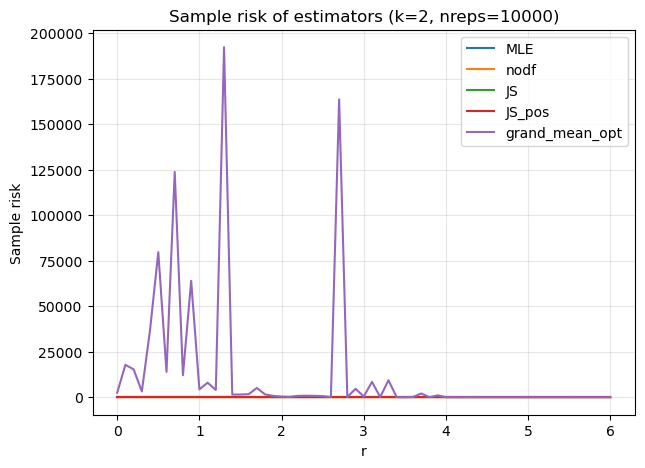

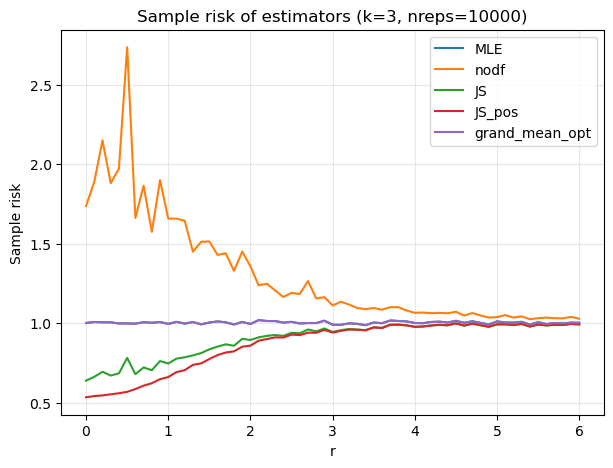

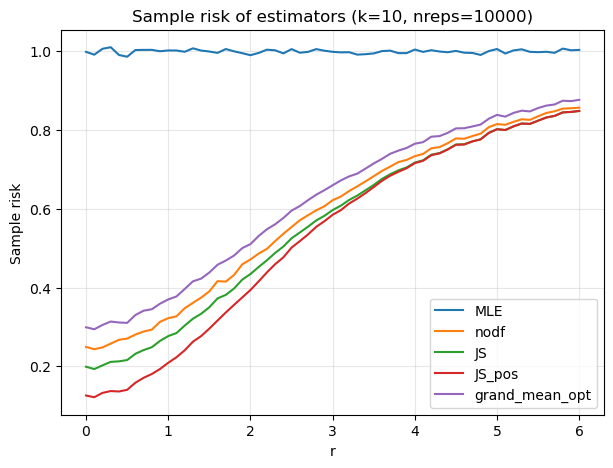

In [ ]:
# container to store risk curves
risks = {}

for k in dim_thetas:
    # print(k)

    # 1. Pick a random vector theta_1 of length 1 
    # (you can pick random normally distributed components and then normalize),
    theta_1 = np.random.normal(size=k)
    theta_1 = theta_1 / np.linalg.norm(theta_1)
    
    # initialise risk curves for each estimator at this dimension
    risks[k] = {'MLE': np.zeros(len(r_grid)),
                'nodf': np.zeros(len(r_grid)),
                'JS': np.zeros(len(r_grid)),
                'JS_pos': np.zeros(len(r_grid)),
                'grand_mean_opt': np.zeros(len(r_grid))}

    for i, r in enumerate(r_grid):

        # 2. take θ = r*theta_1 for r in [0, 6],
        theta = r * theta_1

        # print(f'Dimension: {k}, r: {r}')

        # 3. repeatedly (say, 10,000 times) draw X ∼ N(theta, I),
        X = np.random.multivariate_normal(mean=theta, cov=np.eye(k), size=nreps)

        # mean of Xs, squared Xs, and variance

        # sum of squared X
        X_norm2 = np.sum(X**2, axis=1, keepdims=True)

        # mean of squared X
        X2_bar = X_norm2 / k

        # mean of X
        Xbar = np.mean(X, axis=1, keepdims=True)

        # variance of X
        s2_X = np.mean((X - Xbar) ** 2, axis=1, keepdims=True)

        # print(X2_bar)
        # print(Xbar)
        # print(s2_X)

        # calculate estimates theta_hat

        # 1. the MLE
        thetahat_MLE = X

        # 2. the estimator (1 - 1/X2_bar)*X
        # i think this is the no degrees of freedom thing
        shrink_nodf = 1 - (1 / (X2_bar))
        thetahat_nodf = shrink_nodf * X

        # 3. the James-Stein estimator
        shrink_js = 1 - ((k - 2) / k) / (X2_bar)
        thetahat_js = shrink_js * X

        # 4. the positive part James-Stein estimator,
        # take zero whenever shrinkage factor is negative
        shrink_js_pos = np.maximum(0, shrink_js)
        thetahat_js_pos = shrink_js_pos * X

        # 5. the estimator shrinking to the grand mean using the 
        # optimal shrinkage factor 1 - ((k - 3) / k) / s2_X
        shrink_grand = 1 - (((k - 3) / k) / (s2_X))
        # the estimator is of the form thetahat_i = a + bX_i so thetabar = a + bXbar
        # and E[Xbar] = thetabar, so i'd use the feasible version a = (1 - b)Xbar and b = shrink_grand
        # simplified, this gives us the estimator below
        thetahat_optimal = Xbar + shrink_grand * (X - Xbar)

        # evaluating average loss across all simulation draws for each estimator
        risks[k]['MLE'][i] = np.mean(mse_per_draw(theta, thetahat_MLE))
        risks[k]['nodf'][i] = np.mean(mse_per_draw(theta, thetahat_nodf))
        risks[k]['JS'][i] = np.mean(mse_per_draw(theta, thetahat_js))
        risks[k]['JS_pos'][i] = np.mean(mse_per_draw(theta, thetahat_js_pos))
        risks[k]['grand_mean_opt'][i] = np.mean(mse_per_draw(theta, thetahat_optimal))

    # For a given dimension, plot the risk functions of all these estimators in one figure.
    plt.figure(figsize=(7, 5))
    for name, curve in risks[k].items():
        plt.plot(r_grid, curve, label=name)
    plt.title(f'Sample risk of estimators (k={k}, nreps={nreps})')
    plt.xlabel('r')
    plt.ylabel('Sample risk')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


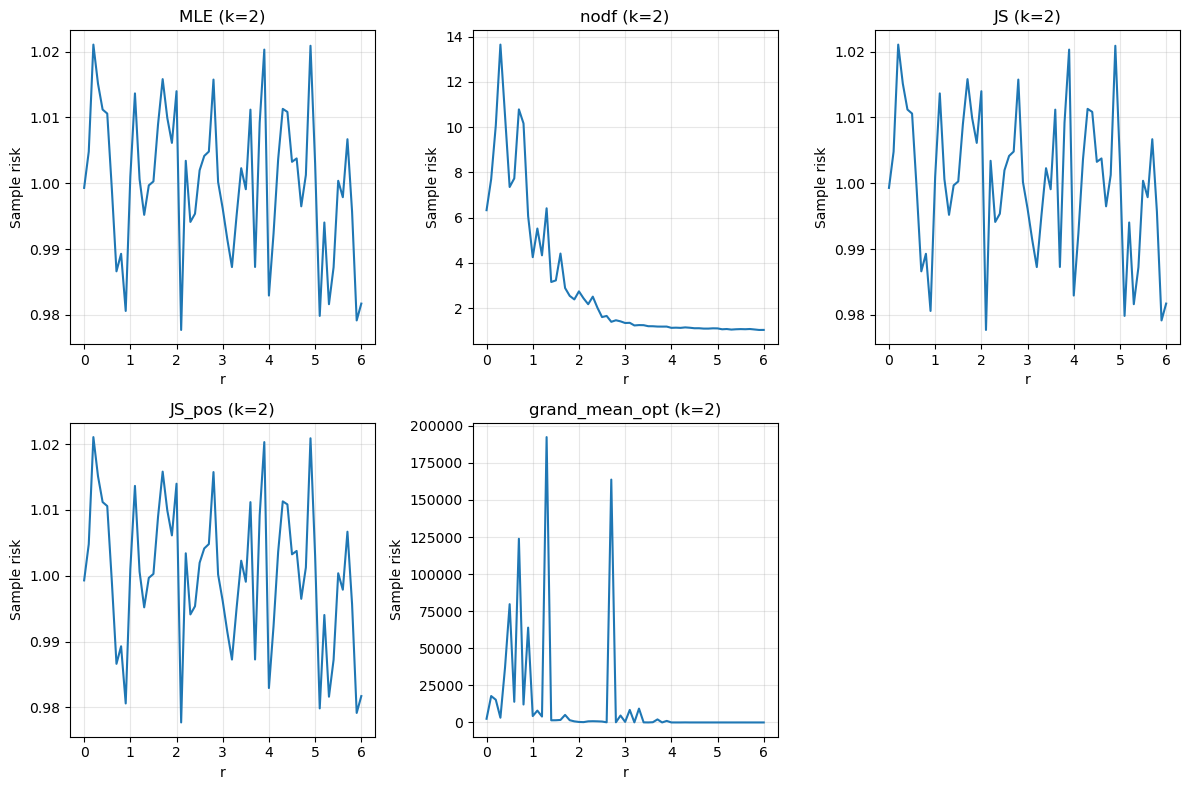

In [4]:
# plot k=2 with separate plot for each estimator to see the differences more clearly
plt.figure(figsize=(12, 8))
k = 2
for i, (name, curve) in enumerate(risks[k].items()):
    plt.subplot(2, 3, i + 1)
    plt.plot(r_grid, curve, label=name)
    plt.title(f'{name} (k={k})')
    plt.xlabel('r')
    plt.ylabel('Sample risk')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

At $k = 2$:

- There are very large spikes in empirical risk for the estimator shrinking to the grand mean. I think this is because the standard deviation that I evaluate for each simulation draw is only caculated using two points, so it's more likely to have a very small sample variance of $X$ by getting two similar $X$ values, which then estimates a very large $\bf{\hat{\theta}}$.
- The MLE risk stays around one since we are drawing the $X$ s from the normal distribution around $\theta$. The normal means model has $X = \theta + \epsilon ~ \text{N}(\theta, \text{I}_k)$ and $\epsilon ∼ \text{N}(0, \text{I}_k)$ so the error is $\hat{\theta} - \theta = X − \theta = \epsilon$ and taking sample mean squared error $\frac{1}{k} ||\hat{\theta} - \theta||^2$ would just be around 1.
- The James-Stein estimator and the MLE are the same based on the formula (the shrinkage factor just goes to 1 since the second term is zero). Hence, the positive part James-Stein estimator is also the same as MLE.
- Meanwhile, the James-Stein estimator with no degrees of freedom correction, $(1 - 1/\bar{\bf{X}^2})*\bf{X}$, is decreasing in sample risk in $r$ but is dominated by regular James-Stein/MLE/positive-part James-Stein. 
- If you think about the MLE, it's unbiased but has risk every extra coordinate adds another unit of the variance part of risk. Shrinkage introduces bias but less variance compared to this. Over-shrinking matters more when $k$ is smaller because the variance of the estimator will already be small as well. In that case, the amount of bias introduced by the shrinking is too large relative to the variance you’re reducing.

At $k = 3$:
- It looks like the MLE estimates and the estimates shrinking to the grand mean both have the same empirical risk of around one for all values of $r$. Since $k = 3$, the optimal shrinkage factor becomes 1. That means the estimator shrinking to the grand mean is the same as the MLE. 
- The positive part James-Stein estimator dominates the James-Stein estimator as the estimated shrinkage factors can be negative when $\bar{X^2} < k−2$ (which would increase error since $X$ and the James-Stein estimate are opposite signs), and both dominate MLE, as seen in the uniform risk dominance result.
- The James-Stein estimator with no degrees of freedom correction, $(1 - 1/\bar{\bf{X}^2})*\bf{X}$, is still decreasing in sample risk in $r$ while the other James-Stein estimators are increasing in sample risk in $r$. It is still dominated by everything else (as in the $k=2$ case) because it's got more bias than MLE (which has zero bias since the estimator is just $X$) and James-Stein, which shrinks less towards zero due to the degrees of freedom corrections.

At $k = 10$:
- The MLE empirical risk still stays around one and the James-Stein estimator with no degrees of freedom correction has slightly lower empirical risk for all values of $r$, but is increasing towards the MLE empirical risk as $r$ increases. The empirical risk for these estimators is higher than that of the positive part James-Stein estimator and the James-Stein estimator. 
-  Now, the James-Stein estimator with no degrees of freedom correction follows the same behaviour as the other James-Stein estimators and dominates MLE. The positive part James-Stein estimator still dominates the James-Stein estimator. The James-Stein estimator, positive part James-Stein estimator, and estimator shrinking to the grand mean are converging to each other as $r$ increases. They are also increasing in $r$. Again, the degrees of freedom correction makes the James-Stein estimator have lower empirical risk because it does correct for how many $\theta_i$ there are and isn't over-shrinking.
- The estimator shrinking to the grand mean is dominated by the James-Stein, positive part James-Stein, and no-degrees-of-freedom-correction James-Stein estimators. I'm guessing it could be because the actual DGP is `theta = r * theta_1` which isn't the same as generating it with an intercept.
- In the James-Stein estimators, the $\bar{\bf{X}^2}$ term makes the shrinkage term be closer to 1 the larger the value of $r$ is, since then the $X$ s come from the distribution determined by $\theta$ and are also larger. This puts it closer to the MLE estimates, making risk improvement over MLE shrinks as $r$ increases. In the estimator shrinking to the grand mean, the variance also increases with r through $\frac{1}{k}\sum_i (\theta_i - \bar\theta)^2 = r^2 \cdot \frac{1}{k}\sum_i (\theta_{1,i} - \bar\theta_1)^2$, with how the $X$ s are generated, which similarly makes this estimator approach MLE.

